In [2]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

In [3]:
# Step 2: Load Dataset
df = pd.read_csv('Phishing_Email.csv')

In [ ]:
#Read Dataset of head
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [5]:
#Read Dataset of tail
df.tail()

,Unnamed: 0,Email Text,Email Type
18645,18646,date a lonely housewife always wanted to date ...,Phishing Email
18646,18647,request submitted : access request for anita ....,Safe Email
18647,18648,"re : important - prc mtg hi dorn & john , as y...",Safe Email
18648,18649,press clippings - letter on californian utilit...,Safe Email
18649,18650,empty,Phishing Email


In [7]:
#Describe
df.describe()

,Unnamed: 0
count,18650.000000
mean,9325.154477
std,5384.327293
min,0.000000
25%,4662.250000
50%,9325.500000
75%,13987.750000
max,18650.000000


In [8]:
# Step 3: Preprocess Dataset
# Drop unnecessary column (Unnamed: 0)
df.drop(columns=['Unnamed: 0'], inplace=True)

In [9]:
# Convert labels to binary (0 for Safe Email, 1 for Phishing Email)
df['Email Type'] = df['Email Type'].map({'Safe Email': 0, 'Phishing Email': 1})

In [10]:
# Clean text data (remove unwanted characters, lowercase)
import re
df['Email Text'] = df['Email Text'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', str(x).lower()))

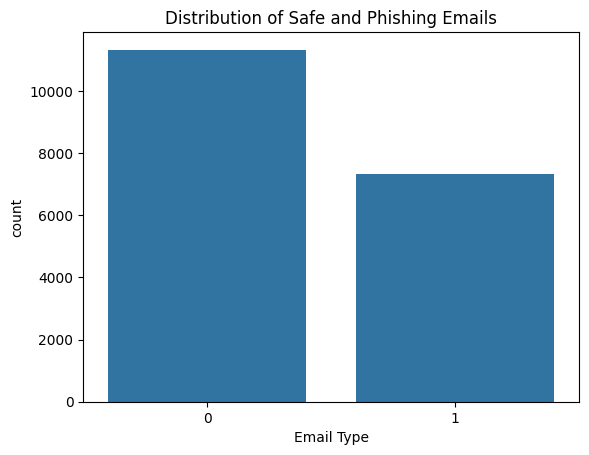

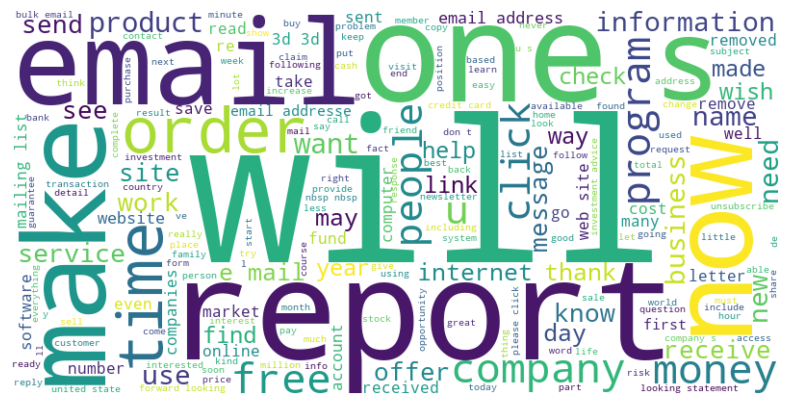

In [12]:
# Step 4: Exploratory Data Analysis (EDA)
# Check class distribution
sns.countplot(x='Email Type', data=df)
plt.title('Distribution of Safe and Phishing Emails')
plt.show()

# Word cloud for phishing emails
from wordcloud import WordCloud
phishing_text = " ".join(df[df['Email Type'] == 1]['Email Text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(phishing_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [13]:
# Step 5: Feature Engineering
# Use TfidfVectorizer to convert text data to numeric form
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['Email Text']).toarray()
y = df['Email Type']

In [25]:
# Step 6: Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [26]:
# Step 6: Initialize Models
models = {
    'SVM': SVC(kernel='linear'),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'XGBoost': XGBClassifier()
}

In [27]:
# Step 7: Train Models and Compare Performance
results = {}
for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test)
    
    # Evaluate model
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    confusion = confusion_matrix(y_test, y_pred)
    
    # Store results
    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score'],
        'Confusion Matrix': confusion
    }

In [28]:
# Step 8: Display Comparison Results
results_df = pd.DataFrame(results).T
print(results_df)

               Accuracy Precision    Recall  F1-Score  \
SVM            0.970152  0.970284  0.970152  0.970187   
Random Forest  0.956211  0.956238  0.956211  0.956223   
XGBoost        0.960143  0.960477  0.960143  0.960221   

                         Confusion Matrix  
SVM              [[3281, 99], [68, 2147]]  
Random Forest  [[3254, 126], [119, 2096]]  
XGBoost         [[3242, 138], [85, 2130]]  


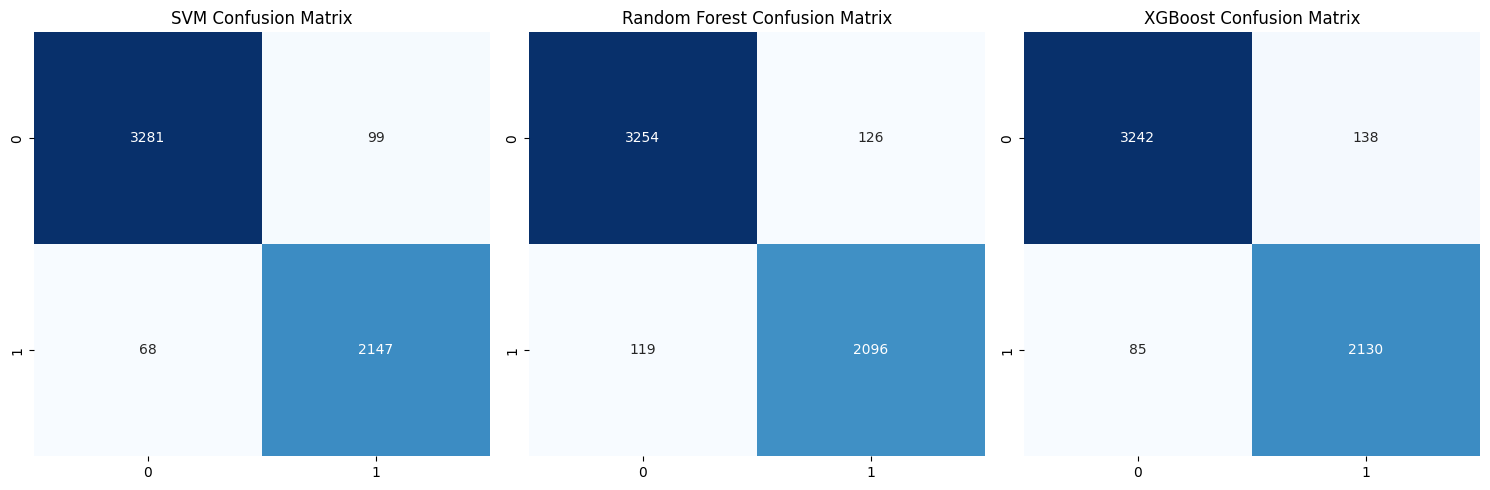

In [29]:
# Step 9: Visualize Confusion Matrices
plt.figure(figsize=(15,5))

for i, (model_name, model_results) in enumerate(results.items(), 1):
    plt.subplot(1, 3, i)
    sns.heatmap(model_results['Confusion Matrix'], annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{model_name} Confusion Matrix')

plt.tight_layout()
plt.show()


In [30]:
# Step 10: Save the Best Model
# Assuming you choose the best model, for example, XGBoost
best_model = models['XGBoost']
joblib.dump(best_model, 'best_phishing_model.pkl')
joblib.dump(vectorizer, 'best_vectorizer.pkl')
print("Best model and vectorizer saved successfully.")

Best model and vectorizer saved successfully.
